## Примерная структура блокнота для задания 2

### 1. Подготовка среды

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split

print("✅ Все библиотеки загружены")

✅ Все библиотеки загружены


### 2. Генерация и визуализация наборов данных

Сгенерируйте набор данных для задачи классификаии

In [10]:
# 2.1. ГЕНЕРАЦИЯ НАБОРА ДАННЫХ ДЛЯ КЛАССИФИКАЦИИ
print("=== ГЕНЕРАЦИЯ НАБОРА ДАННЫХ ===")

# Используем ваш номер 6 как random_state
student_number = 6
X_class, y_class = make_classification(
    n_samples=500,
    n_features=4,
    n_informative=3,
    n_redundant=1,
    n_clusters_per_class=1,
    random_state=student_number
)

print(f"Размер набора: {X_class.shape}")
print(f"Баланс классов: {np.unique(y_class, return_counts=True)}")

# Создаем DataFrame для удобства
feature_names = [f"feature_{i}" for i in range(X_class.shape[1])]
df_class = pd.DataFrame(X_class, columns=feature_names)
df_class['target'] = y_class

print("\nПервые 5 строк данных:")
print(df_class.head())

=== ГЕНЕРАЦИЯ НАБОРА ДАННЫХ ===
Размер набора: (500, 4)
Баланс классов: (array([0, 1]), array([252, 248]))

Первые 5 строк данных:
   feature_0  feature_1  feature_2  feature_3  target
0   3.395399   0.530552  -0.885796  -2.469637       1
1  -1.152437  -1.330708  -0.413121  -0.279498       0
2   1.298676   0.212208  -0.351631  -1.665135       1
3   1.542310   0.822754  -0.065680  -1.506558       1
4   2.464209   0.618455  -0.499985  -1.640483       1


### 3. Разделение данных

Выполните разделение данных на обучающую и тестовую выборки:

In [11]:
print("=== РАЗДЕЛЕНИЕ ДАННЫХ И ОБУЧЕНИЕ МОДЕЛЕЙ ===")

X_train, X_test, y_train, y_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Баланс классов в обучающей выборке: {np.unique(y_train, return_counts=True)}")
print(f"Баланс классов в тестовой выборке: {np.unique(y_test, return_counts=True)}")

# Дерево решений с параметрами по умолчанию
print("\n--- Дерево с параметрами по умолчанию ---")
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

y_pred_default = dt_default.predict(X_test)
accuracy_default = accuracy_score(y_test, y_pred_default)

print(f"Точность (default): {accuracy_default:.4f}")
print(f"Глубина дерева: {dt_default.get_depth()}")
print(f"Количество листьев: {dt_default.get_n_leaves()}")

# Дерево с ограничением глубины (max_depth=3)
print("\n--- Дерево с max_depth=3 ---")
dt_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_limited.fit(X_train, y_train)

y_pred_limited = dt_limited.predict(X_test)
accuracy_limited = accuracy_score(y_test, y_pred_limited)

print(f"Точность (max_depth=3): {accuracy_limited:.4f}")
print(f"Глубина дерева: {dt_limited.get_depth()}")
print(f"Количество листьев: {dt_limited.get_n_leaves()}")

# Сравнение результатов
print(f"\n📊 Сравнение точности:")
print(f"Default: {accuracy_default:.4f}")
print(f"Limited (max_depth=3): {accuracy_limited:.4f}")
print(f"Разница: {accuracy_default - accuracy_limited:.4f}")

# Детальный отчет по классификации
print("\n📋 Детальный отчет по классификации (max_depth=3):")
print(classification_report(y_test, y_pred_limited, target_names=['Class_0', 'Class_1']))

=== РАЗДЕЛЕНИЕ ДАННЫХ И ОБУЧЕНИЕ МОДЕЛЕЙ ===
Обучающая выборка: (400, 4)
Тестовая выборка: (100, 4)
Баланс классов в обучающей выборке: (array([0, 1]), array([200, 200]))
Баланс классов в тестовой выборке: (array([0, 1]), array([52, 48]))

--- Дерево с параметрами по умолчанию ---
Точность (default): 0.9000
Глубина дерева: 8
Количество листьев: 19

--- Дерево с max_depth=3 ---
Точность (max_depth=3): 0.8800
Глубина дерева: 3
Количество листьев: 8

📊 Сравнение точности:
Default: 0.9000
Limited (max_depth=3): 0.8800
Разница: 0.0200

📋 Детальный отчет по классификации (max_depth=3):
              precision    recall  f1-score   support

     Class_0       0.87      0.90      0.89        52
     Class_1       0.89      0.85      0.87        48

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100



### 4. Обучение дерева решений

4.1. Выполните обучение дерева решений с параметрами по умолчанию:

In [13]:
print("=== ОБУЧЕНИЕ ДЕРЕВА РЕШЕНИЙ С ПАРАМЕТРАМИ ПО УМОЛЧАНИЮ ===")

# Обучение дерева решений (по умолчанию)
clf_default = DecisionTreeClassifier(random_state=student_number)
clf_default.fit(X_train, y_train)

# Предсказания и оценка точности
y_pred_default = clf_default.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)

print(f"Точность модели (по умолчанию): {acc_default:.4f}")
print(f"Глубина дерева: {clf_default.get_depth()}")
print(f"Количество листьев: {clf_default.get_n_leaves()}")

print("\n📊 Отчёт по классификации:")
print(classification_report(y_test, y_pred_default, target_names=['Class_0', 'Class_1']))

=== ОБУЧЕНИЕ ДЕРЕВА РЕШЕНИЙ С ПАРАМЕТРАМИ ПО УМОЛЧАНИЮ ===
Точность модели (по умолчанию): 0.9000
Глубина дерева: 8
Количество листьев: 19

📊 Отчёт по классификации:
              precision    recall  f1-score   support

     Class_0       0.94      0.87      0.90        52
     Class_1       0.87      0.94      0.90        48

    accuracy                           0.90       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.90      0.90      0.90       100



4.2. Выполните обучение дерева с ограничением глубины:

In [14]:
print("=== ОБУЧЕНИЕ ДЕРЕВА С ОГРАНИЧЕНИЕМ ГЛУБИНЫ ===")

# Обучение дерева решений с ограничением глубины
clf_depth = DecisionTreeClassifier(max_depth=3, random_state=student_number)
clf_depth.fit(X_train, y_train)

# Предсказания и оценка точности
y_pred_depth = clf_depth.predict(X_test)
acc_depth = accuracy_score(y_test, y_pred_depth)

print(f"Точность модели (max_depth=3): {acc_depth:.4f}")
print(f"Глубина дерева: {clf_depth.get_depth()}")
print(f"Количество листьев: {clf_depth.get_n_leaves()}")

print("\n📊 Отчёт по классификации:")
print(classification_report(y_test, y_pred_depth, target_names=['Class_0', 'Class_1']))

=== ОБУЧЕНИЕ ДЕРЕВА С ОГРАНИЧЕНИЕМ ГЛУБИНЫ ===
Точность модели (max_depth=3): 0.8800
Глубина дерева: 3
Количество листьев: 8

📊 Отчёт по классификации:
              precision    recall  f1-score   support

     Class_0       0.87      0.90      0.89        52
     Class_1       0.89      0.85      0.87        48

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100



### 5. Визуализация дерева

Пример визуализации дерева с ограничением глубины:

=== ВИЗУАЛИЗАЦИЯ ДЕРЕВА С max_depth=3 ===


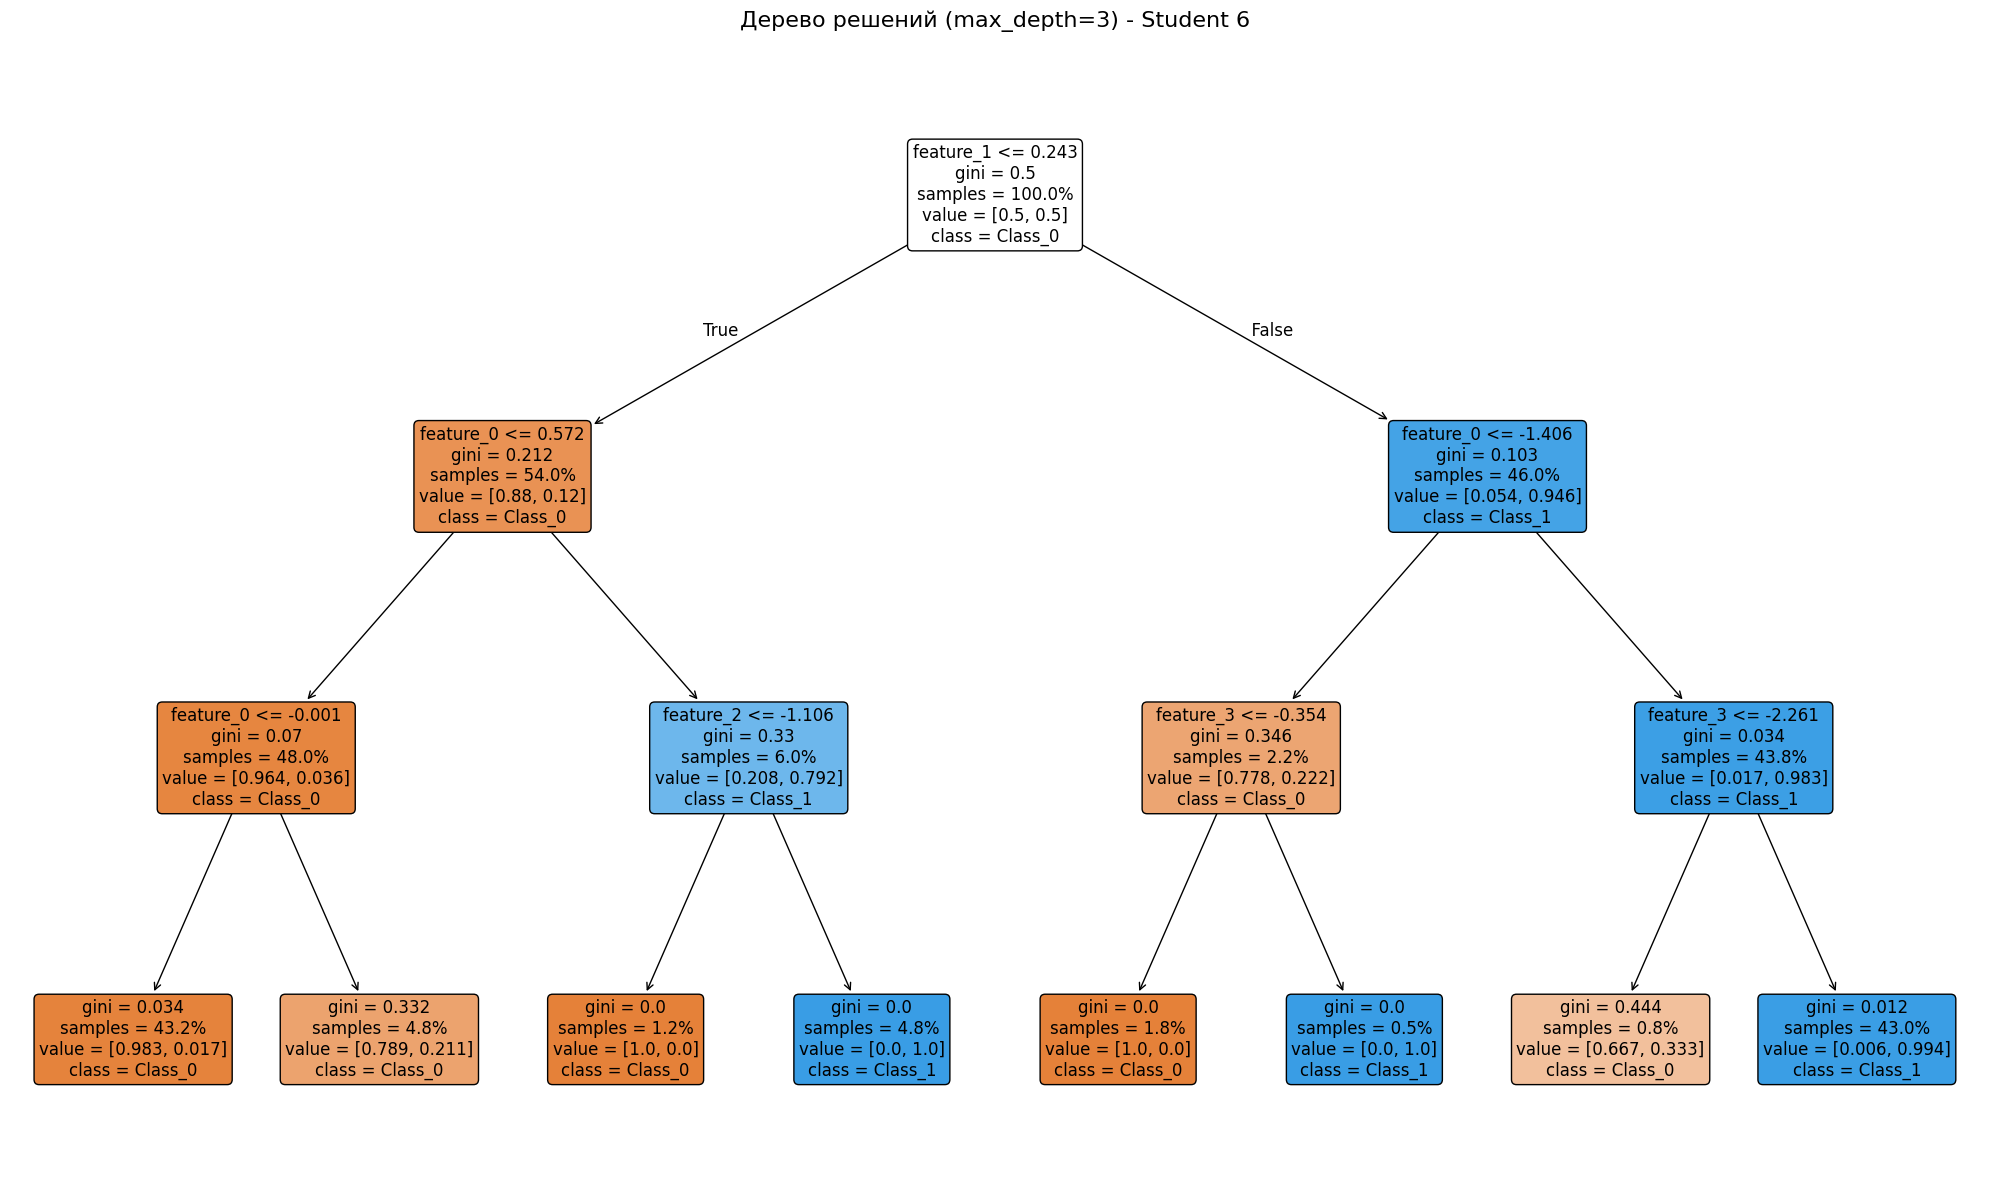

📝 Полные правила дерева решений (max_depth=3):
|--- feature_1 <= 0.24
|   |--- feature_0 <= 0.57
|   |   |--- feature_0 <= -0.00
|   |   |   |--- class: 0
|   |   |--- feature_0 >  -0.00
|   |   |   |--- class: 0
|   |--- feature_0 >  0.57
|   |   |--- feature_2 <= -1.11
|   |   |   |--- class: 0
|   |   |--- feature_2 >  -1.11
|   |   |   |--- class: 1
|--- feature_1 >  0.24
|   |--- feature_0 <= -1.41
|   |   |--- feature_3 <= -0.35
|   |   |   |--- class: 0
|   |   |--- feature_3 >  -0.35
|   |   |   |--- class: 1
|   |--- feature_0 >  -1.41
|   |   |--- feature_3 <= -2.26
|   |   |   |--- class: 0
|   |   |--- feature_3 >  -2.26
|   |   |   |--- class: 1



In [15]:
print("=== ВИЗУАЛИЗАЦИЯ ДЕРЕВА С max_depth=3 ===")

plt.figure(figsize=(20, 12))
plot_tree(clf_depth, 
          feature_names=feature_names,
          class_names=['Class_0', 'Class_1'],
          filled=True,
          rounded=True,
          fontsize=12,
          proportion=True)

plt.title(f'Дерево решений (max_depth=3) - Student {student_number}', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig(f'decision_tree_depth_3_{student_number}.png', dpi=300, bbox_inches='tight')
plt.show()

# Полная текстовая версия правил дерева
print("📝 Полные правила дерева решений (max_depth=3):")
tree_rules_depth = export_text(clf_depth, feature_names=feature_names)
print(tree_rules_depth)

### 6. Сравнение и 

Выполните сравнение моделей с ограничением глубины и без:


=== ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ ТОЧНОСТИ ===


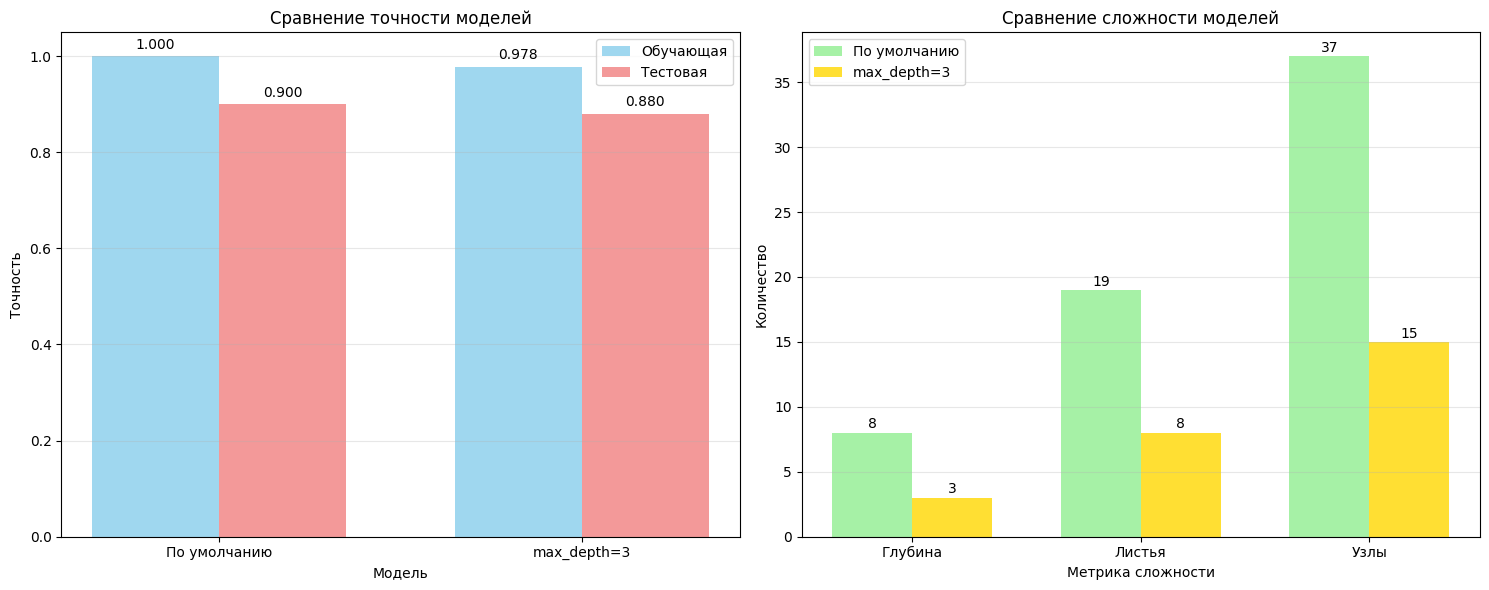

In [20]:
# ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ ТОЧНОСТИ
print("\n=== ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ ТОЧНОСТИ ===")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Сравнение точности
models = ['По умолчанию', 'max_depth=3']
train_accuracies = [train_acc_default, train_acc_depth]
test_accuracies = [acc_default, acc_depth]

x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, train_accuracies, width, label='Обучающая', alpha=0.8, color='skyblue')
bars2 = ax1.bar(x + width/2, test_accuracies, width, label='Тестовая', alpha=0.8, color='lightcoral')

ax1.set_xlabel('Модель')
ax1.set_ylabel('Точность')
ax1.set_title('Сравнение точности моделей')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, acc in zip(bars1, train_accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom')
for bar, acc in zip(bars2, test_accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom')

# График 2: Сравнение сложности моделей
complexity_metrics = ['Глубина', 'Листья', 'Узлы']
default_values = [clf_default.get_depth(), clf_default.get_n_leaves(), clf_default.tree_.node_count]
depth_values = [clf_depth.get_depth(), clf_depth.get_n_leaves(), clf_depth.tree_.node_count]

x2 = np.arange(len(complexity_metrics))
bars3 = ax2.bar(x2 - width/2, default_values, width, label='По умолчанию', alpha=0.8, color='lightgreen')
bars4 = ax2.bar(x2 + width/2, depth_values, width, label='max_depth=3', alpha=0.8, color='gold')

ax2.set_xlabel('Метрика сложности')
ax2.set_ylabel('Количество')
ax2.set_title('Сравнение сложности моделей')
ax2.set_xticks(x2)
ax2.set_xticklabels(complexity_metrics)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, val in zip(bars3, default_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val}', ha='center', va='bottom')
for bar, val in zip(bars4, depth_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f'model_comparison_{student_number}.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
print("=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
print("Сравнение моделей:")
print(f"- Без ограничения глубины: точность = {acc_default:.4f}")
print(f"- С max_depth=3:           точность = {acc_depth:.4f}")

=== СРАВНЕНИЕ МОДЕЛЕЙ ===
Сравнение моделей:
- Без ограничения глубины: точность = 0.9000
- С max_depth=3:           точность = 0.8800


### 7. Выводы

1. Принцип работы дерева решений и алгоритмы ID3, C4.5, CART
Общий принцип: Дерево решений рекурсивно разбивает данные на подмножества, максимизируя "чистоту" узлов через критерии информативности.

2. Разница между энтропией и индексом Джини
Энтропия:

Формула: Entropy = -Σ(p_i * log₂(p_i))

Диапазон: [0, 1]

Более чувствительна к изменениям вероятностей

Вычислительно сложнее

Индекс Джини:

Формула: Gini = 1 - Σ(p_i²)

Диапазон: [0, 0.5]

Менее чувствителен к изменениям

Вычислительно эффективнее

Практический вывод: В scikit-learn используется индекс Джини по умолчанию как более эффективный вариант с сопоставимыми результатами.

3. Переобучение деревьев решений и методы борьбы
Причины переобучения:

Неограниченный рост глубины дерева

Запоминание шума и выбросов

Отсутствие регуляризации